In [1]:
using LinearAlgebra
using DifferentialEquations
using BoundaryValueDiffEq
using Plots
using PyCall
using DelimitedFiles

In [71]:
py"""
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import math
from math import sqrt
Re_s = 20000
def oneDiskODE(z,y):
        # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
        dH = -2 * sqrt(Re_s) * y[1]
        dydz = np.zeros((6, len(z)))
        dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
        return dydz 

def oneDiskBC(ya, yb):
        resa = np.array([ya[0],ya[1], ya[4] - 0])
        
        resb = np.array([yb[0],yb[1], yb[4] - 1])
        
        return np.concatenate((resa, resb))


z = np.linspace(0, 1, 20000)
y = np.zeros((6, len(z)))
y_guess = np.zeros((6, z.size))
y_guess[0] = 1
y_guess[1] = 0
y_guess[2] = 0
y_guess[3] = 0
y_guess[4] = 1
y_guess[5] = 0
solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

x_plot = np.linspace(0, 1, 40000)


y1_plot = solution.sol(x_plot)[0]
y2_plot = solution.sol(x_plot)[1]
y3_plot = solution.sol(x_plot)[4]
y4_plot = solution.sol(x_plot)[2]
y5_plot = solution.sol(x_plot)[5]
"""
Re_s = py"Re_s"
w0 = py"y1_plot"
u0 = py"y2_plot"
v0 = py"y3_plot"
du0 = py"y4_plot"
dv0 = py"y5_plot"
x = py"x_plot"

40000-element Vector{Float64}:
 0.0
 2.500062501562539e-5
 5.000125003125078e-5
 7.500187504687617e-5
 0.00010000250006250156
 0.00012500312507812694
 0.00015000375009375234
 0.00017500437510937773
 0.00020000500012500312
 0.00022500562514062852
 ⋮
 0.999799994999875
 0.9998249956248906
 0.9998499962499062
 0.9998749968749219
 0.9998999974999375
 0.9999249981249532
 0.9999499987499687
 0.9999749993749844
 1.0

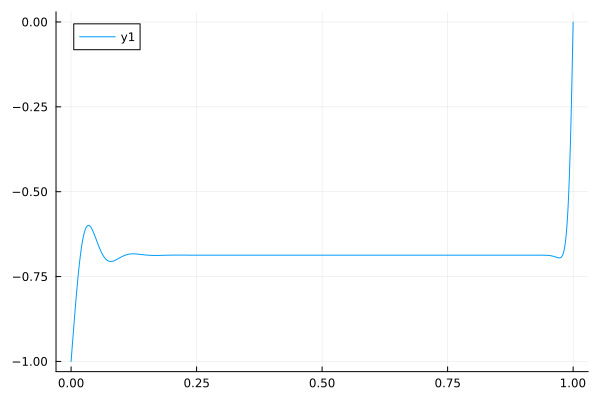

In [73]:
plot(x,v0.-1)

In [60]:
py"""
        import numpy as np
        from scipy.integrate import solve_bvp
        import matplotlib.pyplot as plt
        kappa = -0.687
        def oneDiskODE(z, y):
        
                # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
                dydz = np.zeros((5, len(z)))
                dydz = np.array([-
                                2.0*
                                y[2], kappa * 
                                (y[2] *
                                y[2] +
                                    y[0] *
                                    y[1] -
                                    (y[4] *
                                    y[4]- 
                                    1.0)) -
                                (2.0 -
                                    kappa - 
                                    kappa**2) *
                                (y[4] -
                                    1.0), y[1], kappa *
                                (2.0 * 
                                    y[2] *
                                    y[4] +
                                    y[0] *
                                    y[3]) +
                                (2.0 -
                                    kappa -
                                    kappa**2) *
                                y[2], y[3]])
                return dydz 
        
        def oneDiskBC(ya, yb):
                resa = np.array([ya[0],
                                ya[2],
                                ya[4]])
                
                resb = np.array([yb[2],
                                yb[4] - 1.0])
                
                return np.concatenate((resa, resb))
        
        
        z = np.linspace(0, 30, 20000)
        y = np.zeros((5, len(z)))
        y_guess = np.zeros((5, z.size))
        if kappa == 1:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        elif kappa == -1:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        else:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        
        
        
        
        solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,tol=1e-10,max_nodes=5000000)
        
        x_plot = np.linspace(0, 30, 20000)
        
        
        y1_plot = solution.sol(x_plot)[0]
        y2_plot = solution.sol(x_plot)[2]
        y3_plot = solution.sol(x_plot)[4]
        y4_plot = solution.sol(x_plot)[1]
        y5_plot = solution.sol(x_plot)[3]
        
        """
        w2 = py"y1_plot"
        u2 = py"y2_plot"
        v2 = py"y3_plot"
        du2 = py"y4_plot"
        dv2 = py"y5_plot"
        x2 = py"x_plot"

20000-element Vector{Float64}:
  0.0
  0.0015000750037501875
  0.003000150007500375
  0.004500225011250562
  0.00600030001500075
  0.0075003750187509375
  0.009000450022501124
  0.010500525026251312
  0.0120006000300015
  0.013500675033751687
  ⋮
 29.987999399969997
 29.989499474973748
 29.9909995499775
 29.99249962498125
 29.993999699984997
 29.995499774988748
 29.9969998499925
 29.99849992499625
 30.0

In [ ]:
x3

In [43]:
velocity = [x u0 v0 w0 du0 dv0]
writedlm("Re_s = $Re_s.dat", velocity)

In [10]:
400 * 0.35

140.0

In [11]:
nu = 1.51 * 10 ^ (-5)
OMEGA = 400
delta = sqrt(nu/OMEGA)
s = 0.15
Res = (s/delta)^2


596026.4900662252

In [61]:
u_merge = [u2[1:end,1];u1[end:-1:1,1]]
v_merge = [v2[1:end,1];v1[end:-1:1,1]]
x_merge = [x1[1:end,1];x1[end:-1:1,1]]

40000-element Vector{Float64}:
 0.0
 0.0015000750037501875
 0.003000150007500375
 0.004500225011250562
 0.00600030001500075
 0.0075003750187509375
 0.009000450022501124
 0.010500525026251312
 0.0120006000300015
 0.013500675033751687
 ⋮
 0.0120006000300015
 0.010500525026251312
 0.009000450022501124
 0.0075003750187509375
 0.00600030001500075
 0.004500225011250562
 0.003000150007500375
 0.0015000750037501875
 0.0

In [62]:
u_merge

40000-element Vector{Float64}:
  0.0
 -0.0011387057770755116
 -0.0022739793530400904
 -0.0034058269359425104
 -0.004534254728991793
 -0.005659268930541229
 -0.006780875734072494
 -0.007899081328179854
 -0.009013891896554462
 -0.010125313617968746
  ⋮
 -0.011853238143662861
 -0.010383572259913208
 -0.008910486215654075
 -0.007433977386309601
 -0.0059540431529562805
 -0.004470680902344079
 -0.002983888026917571
 -0.0014936619248371063
  5.2419663767532585e-21

In [57]:
maximum(u0)/maximum(-u_merge)

0.48941090446013397